
### Objective :  To analyze e-commerce Sales data to identify key growth drivers and optimize operational efficiency.


### Step1 : Environment Setup & Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/sales_dataset.csv")

/tmp/ipykernel_367/393466937.py:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/sales_dataset.csv")


### Step2 : Data Exploration & Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [4]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [5]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [6]:
df.loc[df['Status']=='Cancelled','Amount'] = 0

In [7]:
df['Amount'] = df['Amount'].fillna(df['Amount'].median())     #fill missing amount values with median

In [8]:
df.duplicated().sum()

np.int64(6)

In [9]:
df.drop_duplicates(inplace=True)          #remove duplicate rows to ensure data integrity

In [10]:
df['Date']= pd.to_datetime(df['Date'])    #convert date column to datetime format for time-series analysis

/tmp/ipykernel_367/2023209925.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']= pd.to_datetime(df['Date'])    #convert date column to datetime format for time-series analysis


In [11]:
df.dropna(subset=['ship-city','ship-state','ship-postal-code', 'ship-country'],inplace = True) #drop rows with missing location details for geographical accuracy

In [12]:
df['currency']= df['currency'].fillna('INR')    #impute missing currenvcy as 'INR'

In [13]:
df.loc[(df['Courier Status'].isnull()) &(df['Status']=='Cancelled'),'Courier Status'] = 'Unshipped' #impute missing courier status based on order status
df['Courier Status'] = df['Courier Status'].fillna('Shipped')

In [14]:
df.drop(['promotion-ids','fulfilled-by','Unnamed: 22'],axis=1,inplace=True,errors='ignore')  #drop redundant and high null columns(over 70%) to clean dataset

In [15]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [16]:
df.describe()

,Date,Qty,Amount,ship-postal-code
count,128910,128910.000000,128910.000000,128910.00000
mean,2022-05-12 11:48:37.700721408,0.904662,556.633873,463978.72546
min,2022-03-31 00:00:00,0.000000,0.000000,110001.00000
25%,2022-04-20 00:00:00,1.000000,376.000000,382421.00000
50%,2022-05-10 00:00:00,1.000000,545.000000,500033.00000
75%,2022-06-04 00:00:00,1.000000,760.000000,600024.00000
max,2022-06-29 00:00:00,15.000000,5584.000000,989898.00000
std,NaN,0.314745,346.487386,191471.57590


In [17]:
df.shape

(128910, 20)

## Financial Performance Analysis

### #Total Revenue Growth Over Time

In [18]:
total_revenue = df["Amount"].sum()
print("Total Revenue: ",total_revenue)

Total Revenue:  71755672.62


In [19]:
Total_orders = df["Order ID"].nunique()
print("Total Orders:",Total_orders)

Total Orders: 120324


In [75]:
AOV = total_revenue/Total_orders
print(f"Average Order Value: {AOV:.2f}")

Average Order Value: 596.35


### #Monthly Sales Trend

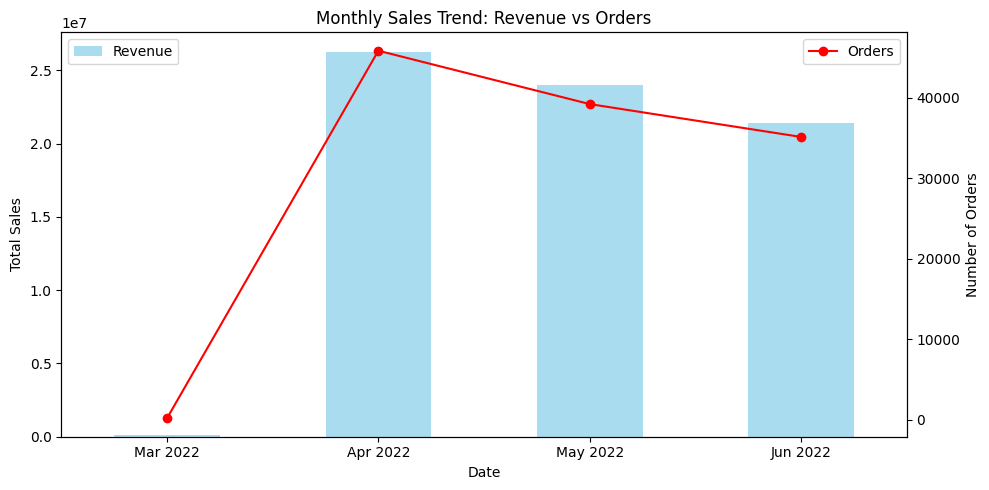

In [85]:
plt.figure(figsize=(10,5))
monthly_sales = df.resample('ME', on='Date')['Amount'].sum()
monthly_order = df.resample('ME', on='Date')['Order ID'].nunique()
ax1 = monthly_sales.plot(kind='bar', color='skyblue', alpha=0.7, label = "Revenue")
ax1.set_ylabel('Total Sales')
ax2 = ax1.twinx()
ax2.plot(range(len(monthly_order)), monthly_order.values, color='red', marker='o',label = "Orders")
ax2.set_ylabel('Number of Orders')
ax1.set_xticklabels([x.strftime('%b %Y') for x in monthly_sales.index], rotation=0)
plt.title('Monthly Sales Trend: Revenue vs Orders')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### #Weekly Sales Trend

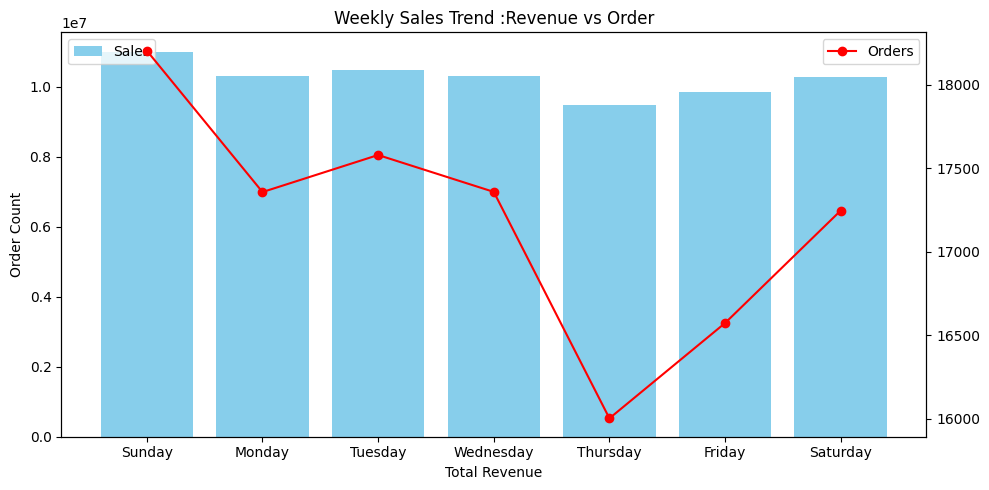

In [87]:
df['Day'] = df['Date'].dt.day_name()
days_order =['Sunday', 'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
weekly_rev = df.groupby('Day')['Amount'].sum().reindex(days_order)
weekly_ord = df.groupby('Day')['Order ID'].nunique().reindex(days_order)
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(weekly_rev.index, weekly_rev, color='skyblue',label ="Sales")
ax1.set_xlabel('Total Revenue')
ax1.set_ylabel('Order Count')
ax2 = ax1.twinx()
ax2.plot(weekly_rev.index, weekly_ord.values, marker='o', color='red', label="Orders")
weekly_sales = df.resample('W',on='Date')['Amount'].sum()
plt.title('Weekly Sales Trend :Revenue vs Order')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

Identifying Best-Selling Products (By Quantity)

Top 10 Best Selling Products:
SKU              Category     
SET268-KR-NP-XL  Set              373
JNE3797-KR-XS    Western Dress    386
JNE3405-KR-S     kurta            399
JNE3797-KR-XL    Western Dress    416
J0230-SKD-S      Set              421
J0230-SKD-M      Set              468
JNE3405-KR-L     kurta            485
JNE3797-KR-S     Western Dress    503
JNE3797-KR-M     Western Dress    560
JNE3797-KR-L     Western Dress    661
Name: Qty, dtype: int64


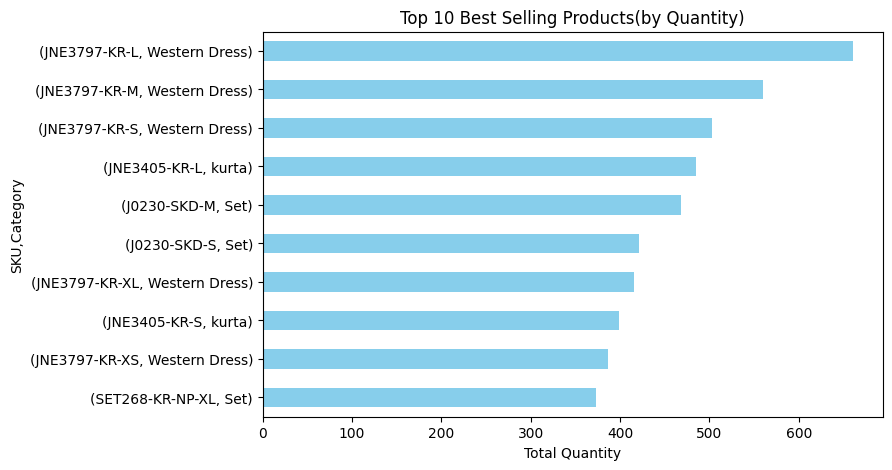

In [22]:
top_products_qty= df.groupby(["SKU", "Category"])["Qty"].sum().sort_values(ascending=True).tail(10)
print("Top 10 Best Selling Products:")
print(top_products_qty)
top_products_qty.plot(kind='barh', figsize=(8,5), color = 'skyblue')
plt.title('Top 10 Best Selling Products(by Quantity)')
plt.xlabel('Total Quantity')
plt.show()

Identifying Best-Selling Products (By Revenue)

In [23]:
top_products_rev= df.groupby(["SKU","Category"])["Amount"].sum().sort_values(ascending=False).head(10)
print("Top 10 Best Selling Products(by Revenue:")
print(top_products_rev)

Top 10 Best Selling Products(by Revenue:
SKU              Category     
J0230-SKD-M      Set              482448.0
JNE3797-KR-L     Western Dress    469312.0
J0230-SKD-S      Set              448825.0
JNE3797-KR-M     Western Dress    403115.0
JNE3797-KR-S     Western Dress    360194.0
JNE3797-KR-XL    Western Dress    302519.0
J0230-SKD-L      Set              278223.0
JNE3797-KR-XS    Western Dress    274609.0
SET268-KR-NP-XL  Set              261246.0
JNE3797-KR-XXL   Western Dress    253211.0
Name: Amount, dtype: float64


## customer Insight Analysis



Top-performing locations based on Sales Volume

Top 10 States by Sales Volume :
                  Qty       Amount
ship-state                        
MAHARASHTRA     20325  12233176.00
KARNATAKA       15901   9648329.00
TAMIL NADU      10414   5958817.00
TELANGANA       10255   6293653.57
UTTAR PRADESH    9496   6184515.00
DELHI            6155   3907340.48
KERALA           5815   3378602.00
WEST BENGAL      5316   3208055.00
ANDHRA PRADESH   4819   2886567.00
Gujarat          4152   2554518.00


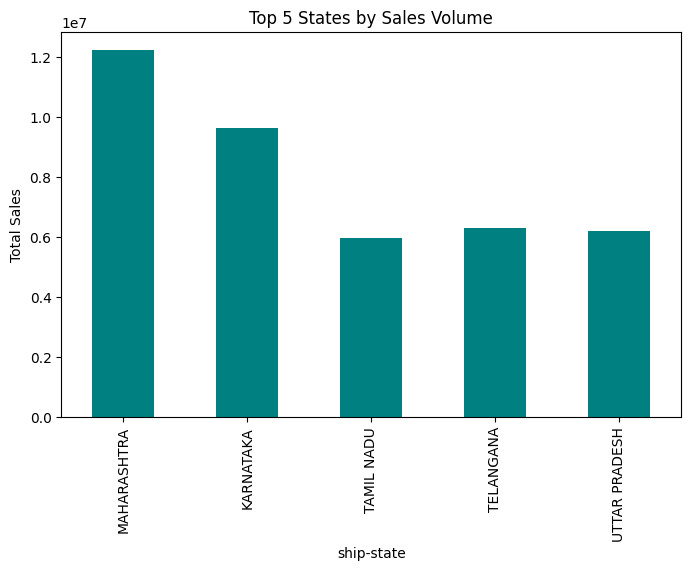

In [24]:
top_states_volume = df.groupby('ship-state').agg({'Qty':'sum','Amount':'sum'}).sort_values(by='Qty',ascending=False).head(10)
print("Top 10 States by Sales Volume :")
print( top_states_volume)
top_states_volume['Amount'].head(5).plot(kind='bar', figsize=(8,5),color = 'teal')
plt.title('Top 5 States by Sales Volume')
plt.ylabel('Total Sales')
plt.show()

### Top 5 City By Revenue

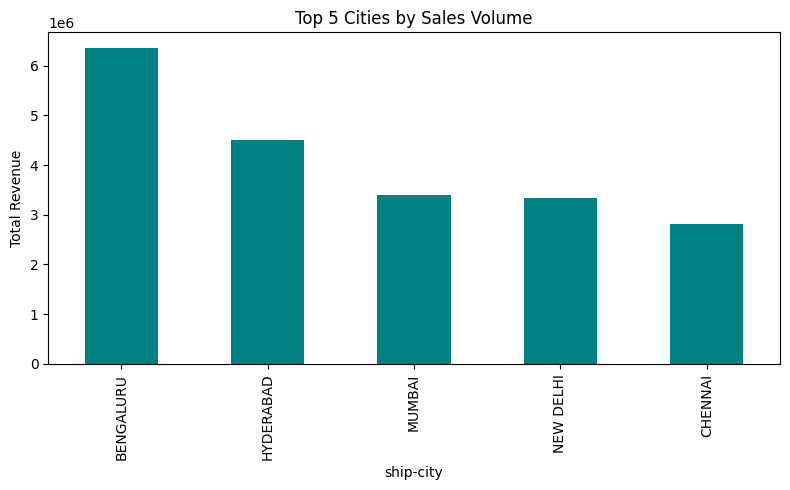

In [70]:
top_cities = df.groupby('ship-city').agg({'Qty': 'sum','Amount':'sum'}).sort_values(by = 'Amount' ,ascending=False).head(5)
plt.figure(figsize=(8,5))
top_cities['Amount'].plot(kind='bar',color = 'teal')
plt.title('Top 5 Cities by Sales Volume')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

Analyzing Order Cancellation Trends

In [25]:
status_count = df['Status'].value_counts()
total_orders= len(df)
cancelled_orders = status_count.get('Cancelled',0)
cancellation_rate = (cancelled_orders/total_orders)*100
print("total Orders:", total_orders)
print("Cancelled Orders:",cancelled_orders)
print("Cancellation Rate:",cancellation_rate)

total Orders: 128910
Cancelled Orders: 18331
Cancellation Rate: 14.219998448529983


In [26]:
cancellation_trend = df[df['Status'] == 'Cancelled'].groupby('Date').size()
print("Cancellation Trend:",cancellation_trend)

Cancellation Trend: Date
2022-03-31     18
2022-04-01    234
2022-04-02    256
2022-04-03    241
2022-04-04    198
             ... 
2022-06-25    129
2022-06-26    158
2022-06-27    140
2022-06-28    162
2022-06-29     31
Length: 91, dtype: int64


Differentiating B2B vs B2C Customer Behavior



B2B vs B2C Customer Behavior:
       Unique_Orders  Avg_Order_Value     Qty
B2B                                          
False         119530       556.047201  115779
True             794       642.876005     841


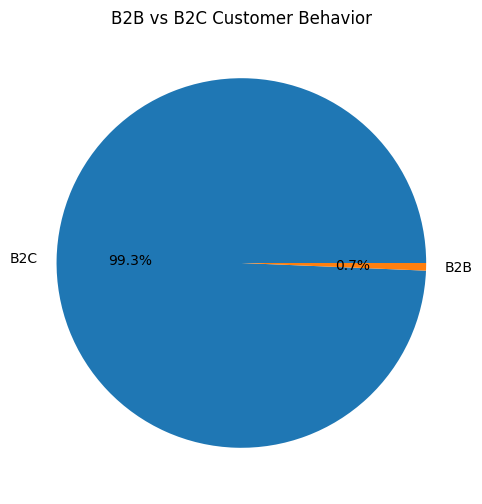

In [27]:
b2b_vs_b2c = df.groupby('B2B').agg({'Order ID': 'nunique','Amount':'mean','Qty':'sum'}).rename(columns={'Order ID':'Unique_Orders','Amount':'Avg_Order_Value'})
print("B2B vs B2C Customer Behavior:")
print(b2b_vs_b2c)
b2b_vs_b2c['Unique_Orders'].plot(kind='pie',figsize=(6,6),color = ['skyblue', 'lightcoral'], labels =["B2C","B2B"],autopct ='%1.1f%%')
plt.title('B2B vs B2C Customer Behavior')
plt.ylabel('')
plt.show()

## LOGISTICS & FULFILLMENT OPTIMIZATION

Addressing Shipping Delays By Calculating Average Shipping Times

In [28]:
shipping_efficiency = pd.crosstab( df['ship-service-level'],df['Status'],normalize = 'index')*100
print("Shipping Efficiency Status % by Service level:")
print(shipping_efficiency)

Shipping Efficiency Status % by Service level:
Status              Cancelled   Pending  Pending - Waiting for Pick Up  \
ship-service-level                                                       
Expedited           12.898273  0.466298                       0.000000   
Standard            17.121963  0.607338                       0.696579   

Status                Shipped  Shipped - Damaged  \
ship-service-level                                 
Expedited           86.624139           0.000000   
Standard             2.540902           0.002479   

Status              Shipped - Delivered to Buyer  Shipped - Lost in Transit  \
ship-service-level                                                            
Expedited                               0.011291                   0.000000   
Standard                               71.279127                   0.012395   

Status              Shipped - Out for Delivery  Shipped - Picked Up  \
ship-service-level                                         

Comparing orders fulfilled by Amazon vs.
Merchant fullfilment

In [29]:
fulfillment_analysis = df.groupby('Fulfilment').agg({'Order ID':'nunique','Amount':'sum'}).rename(columns={'Order ID':'Total Orders','Amount':'Total Revenue'})
print("Fulfillment Analysis:")
print(fulfillment_analysis)

Fulfillment Analysis:
            Total Orders  Total Revenue
Fulfilment                             
Amazon             83967    50680254.00
Merchant           36357    21075418.62


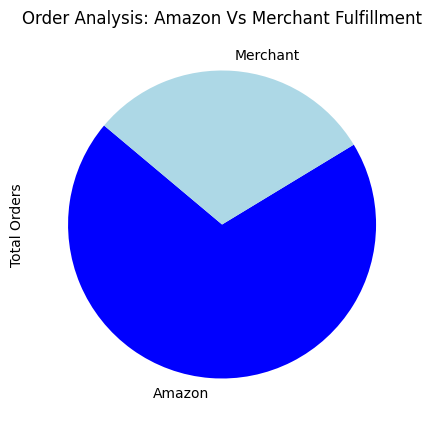

In [30]:
plt.figure(figsize=(6,5))
fulfillment_analysis['Total Orders'].plot(kind='pie',startangle = 140, colors = ['blue','lightblue'])
plt.title('Order Analysis: Amazon Vs Merchant Fulfillment')
plt.show()

Improving order processing for faster Deliveries

In [31]:
top_Processing_states = df.groupby('ship-state')['Order ID'].nunique().sort_values(ascending=False).head(5)
print("Top 5 States by Order Processing:")
print(top_Processing_states)

Top 5 States by Order Processing:
ship-state
MAHARASHTRA      20777
KARNATAKA        16177
TAMIL NADU       10517
TELANGANA        10402
UTTAR PRADESH    10060
Name: Order ID, dtype: int64


## PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION

Identifying high-demand product categories


High DemandmCategories:
Category
Set              45275
kurta            45034
Western Dress    13942
Top               9900
Ethnic Dress      1052
Blouse             864
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64


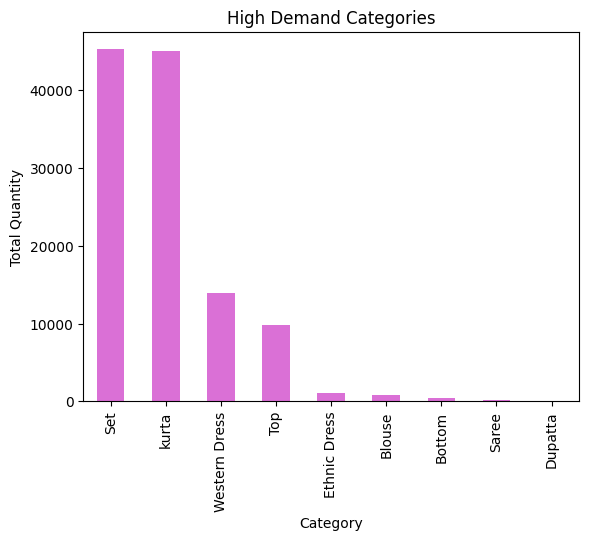

In [32]:
high_demand_categories = df.groupby('Category')['Qty'].sum().sort_values(ascending= False)
print("High DemandmCategories:")
print(high_demand_categories)
high_demand_categories.plot(kind ='bar',color = 'orchid')
plt.title('High Demand Categories')
plt.ylabel('Total Quantity')
plt.show()

Analyzing the average quantity ordered for efficient stock management

In [33]:
avg_quantity = df['Qty'].mean()
print(f"Average Quantity Ordered: {avg_quantity:.2f}")

Average Quantity Ordered: 0.90


Enhancing inventory control to prevent stockouts or overstocking

In [34]:
size_demand = df.groupby('Size')['Qty'].sum().sort_values(ascending = False)
print("Inventory Control(Demand by Size);")
print(size_demand)

Inventory Control(Demand by Size);
Size
M       20444
L       19984
XL      18925
XXL     16508
S       15333
3XL     13524
XS       9938
6XL       688
5XL       513
4XL       395
Free      368
Name: Qty, dtype: int64


## CUSTOMER SATISFACTION & RETURNS


### Monthly Cancellation Rate

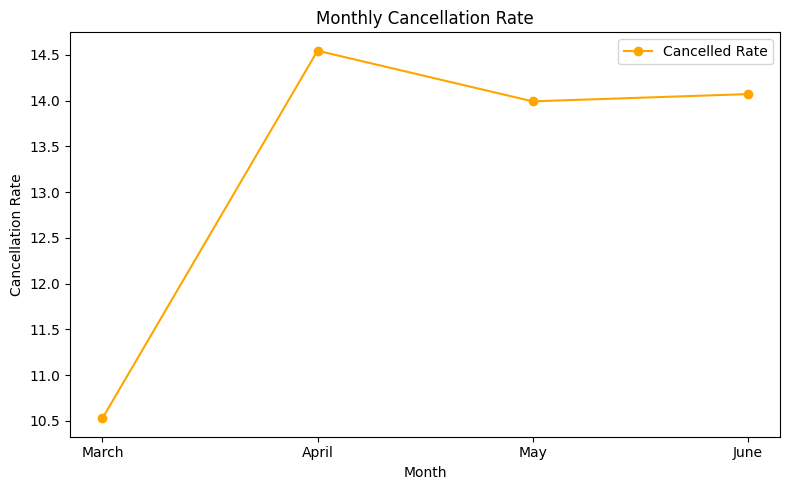

In [102]:
monthly_stats= df.groupby(df['Date'].dt.strftime('%B'))['Status'].value_counts(normalize=True).unstack()*100
month_order = ['March', 'April','May','June']
monthly_stats = monthly_stats.reindex(month_order)
plt.figure(figsize=(8,5))
plt.plot(monthly_stats.index,monthly_stats['Cancelled'], marker ='o',color = 'orange', label = 'Cancelled Rate')
plt.title('Monthly Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.legend()
plt.tight_layout()
plt.show()



Investigating high return and cancellation rates

In [36]:
status_satisfaction = df['Status'].value_counts(normalize = True)*100
print("Overall Satisfaction Status:")
print(status_satisfaction.map(lambda x: f'{x:.2f}%'))

Overall Satisfaction Status:
Status
Shipped                          60.31%
Shipped - Delivered to Buyer     22.31%
Cancelled                        14.22%
Shipped - Returned to Seller      1.51%
Shipped - Picked Up               0.75%
Pending                           0.51%
Pending - Waiting for Pick Up     0.22%
Shipped - Returning to Seller     0.11%
Shipped - Out for Delivery        0.03%
Shipped - Rejected by Buyer       0.01%
Shipping                          0.01%
Shipped - Lost in Transit         0.00%
Shipped - Damaged                 0.00%
Name: proportion, dtype: object


Identifying problematic products/categories to enhance quality

Top 10 Problematic Categories:
Category       SKU           
Western Dress  JNE3797-KR-L      148
               JNE3797-KR-M      122
               JNE3797-KR-S      120
kurta          JNE3405-KR-L       88
Western Dress  JNE3797-KR-XL      82
kurta          JNE3405-KR-M       76
Western Dress  JNE3797-KR-XS      75
Set            J0230-SKD-M        75
               J0003-SET-S        72
               SET268-KR-NP-S     71
dtype: int64


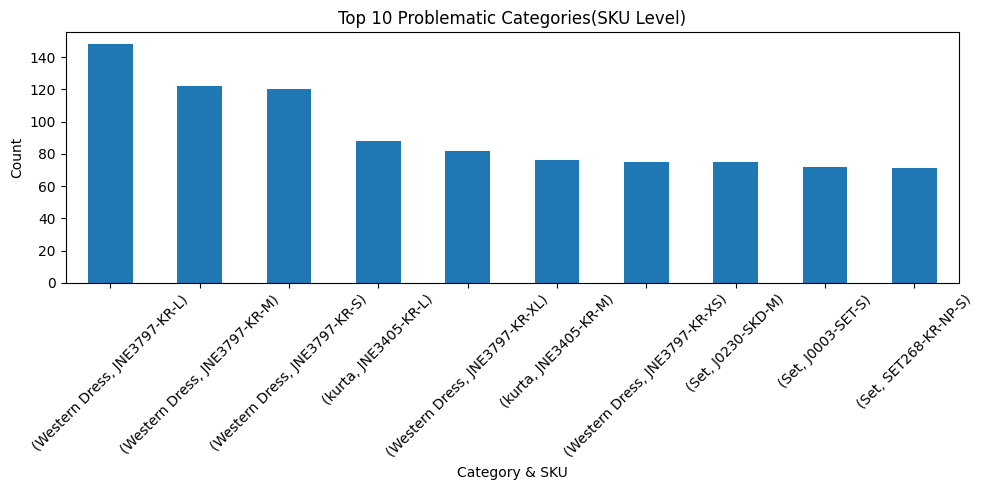

In [37]:
problem_categories = df[df['Status'].isin(['Cancelled','Shipped - Returned to Seller'])].groupby(['Category','SKU']).size().sort_values(ascending = False).head(10)
print("Top 10 Problematic Categories:")
print(problem_categories)
plt.figure(figsize=(10,5))
problem_categories.plot(kind='bar')
plt.title('Top 10 Problematic Categories(SKU Level)')
plt.xlabel('Category & SKU')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Conclusion
####So, after analyzing the dataset,I found that the Total revenue generated was around ₹71.77M, with a massive sales peak in April 2022 where revenue reached approx ₹26.27M.
####When we loook at customer segment, almost 99% of orders comes from B2C customers,which means the businmess is retail-focused.Geographically,most of orders are coming from orders Maharashtra and Karnataka.
###In terms of product demand, 'Sets' and 'Kurtas' are the most demanded categories. However, the  business faces a cancellation rate of 14.22%, which indicates there might be operational or product related issue that needs attention.
###Recommendations:
###Based on these insights,a few recommendations can be suggested.
#### First, The company Should maintain higher buffer stocks for popular size M, L, and XL sizes in top selling categories to avoid stockouts.
#### Second, there is specific product SKU JNE3797-KR-L in Western Dress show high number of  returns  and cancellations. the product should be investigate to understand possible reason behind it.
####Third, since Maharashtra generates the highest revenue, the company can focus more on marketing and logistics in this region that could help increases overall sales.
####Lastly, Regularly monitoring weekly sales and cancellation trends can help the business to respond quickly to seasonal demand changes and improve overall operational efficiency.